#**Telecom X - Parte 2: Predicción de Cancelación**
#Introducción

En esta segunda parte del desafío, el objetivo es construir modelos predictivos capaces de identificar clientes con mayor probabilidad de cancelación (churn). Para ello, se utilizará el conjunto de datos tratado en la Parte 1, aplicando técnicas de preparación de datos, codificación de variables, análisis de correlación, entrenamiento de modelos de clasificación y evaluación de desempeño.

El propósito final es apoyar a Telecom X en la identificación temprana de clientes en riesgo y en la creación de estrategias de retención más efectivas.

##Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

##Cargue del CSV tratado

In [3]:
df = pd.read_csv('/content/datos_tratados.csv')
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].mean())
df.head()

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,daily_charges
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [4]:
df.to_csv("datos_tratados.csv", index=False)

#Exploración inicial

In [5]:
df.shape

(7043, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   churn              7043 non-null   int64  
 2   gender             7043 non-null   object 
 3   senior_citizen     7043 non-null   int64  
 4   partner            7043 non-null   int64  
 5   dependents         7043 non-null   int64  
 6   tenure             7043 non-null   int64  
 7   phone_service      7043 non-null   int64  
 8   multiple_lines     7043 non-null   object 
 9   internet_service   7043 non-null   object 
 10  online_security    7043 non-null   object 
 11  online_backup      7043 non-null   object 
 12  device_protection  7043 non-null   object 
 13  tech_support       7043 non-null   object 
 14  streaming_tv       7043 non-null   object 
 15  streaming_movies   7043 non-null   object 
 16  contract           7043 

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
total_charges,11
customer_id,0
gender,0
senior_citizen,0
partner,0
churn,0
dependents,0
tenure,0
multiple_lines,0
phone_service,0


In [8]:
df.head()

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,daily_charges
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


##Verificación de la proporción de churn

In [9]:
df['churn'].value_counts()

,count
churn,
0,5174
1,1869


In [10]:
(df['churn'].value_counts(normalize=True) * 100).round(2)

,proportion
churn,
0,73.46
1,26.54


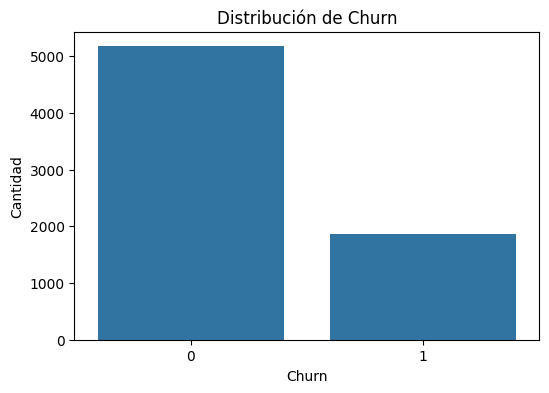

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.show()

Se verificó la proporción de clientes que cancelaron frente a los que permanecieron. Este paso es importante porque un desbalance de clases puede afectar el rendimiento de los modelos predictivos, especialmente en métricas como accuracy.

##Eliminación de columnas irrelevantes

In [12]:
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

In [13]:
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

Se eliminó la columna identificadora del cliente porque no aporta valor predictivo. Los identificadores únicos no representan comportamiento ni características útiles para anticipar la cancelación.

#Separación variable objetivo y predictoras

In [18]:
X = df.drop(columns=['churn'])
y = df['churn']

##Identificación variables categóricas y numéricas

In [19]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:", cat_cols)
print("Variables numéricas:", num_cols)

Variables categóricas: ['gender', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'payment_method']
Variables numéricas: ['senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'paperless_billing', 'monthly_charges', 'total_charges', 'daily_charges']


##Encoding

In [20]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,daily_charges,gender_Male,...,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.186667,False,...,True,False,True,True,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,1.996667,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.463333,True,...,False,True,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.266667,True,...,True,True,False,True,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.796667,False,...,False,False,True,True,False,False,False,False,False,True


Se aplicó one-hot encoding a las variables categóricas para convertirlas en variables numéricas compatibles con los algoritmos de machine learning. Se utilizó `drop_first=True` para evitar redundancia entre categorías.

#Análisis de correlación

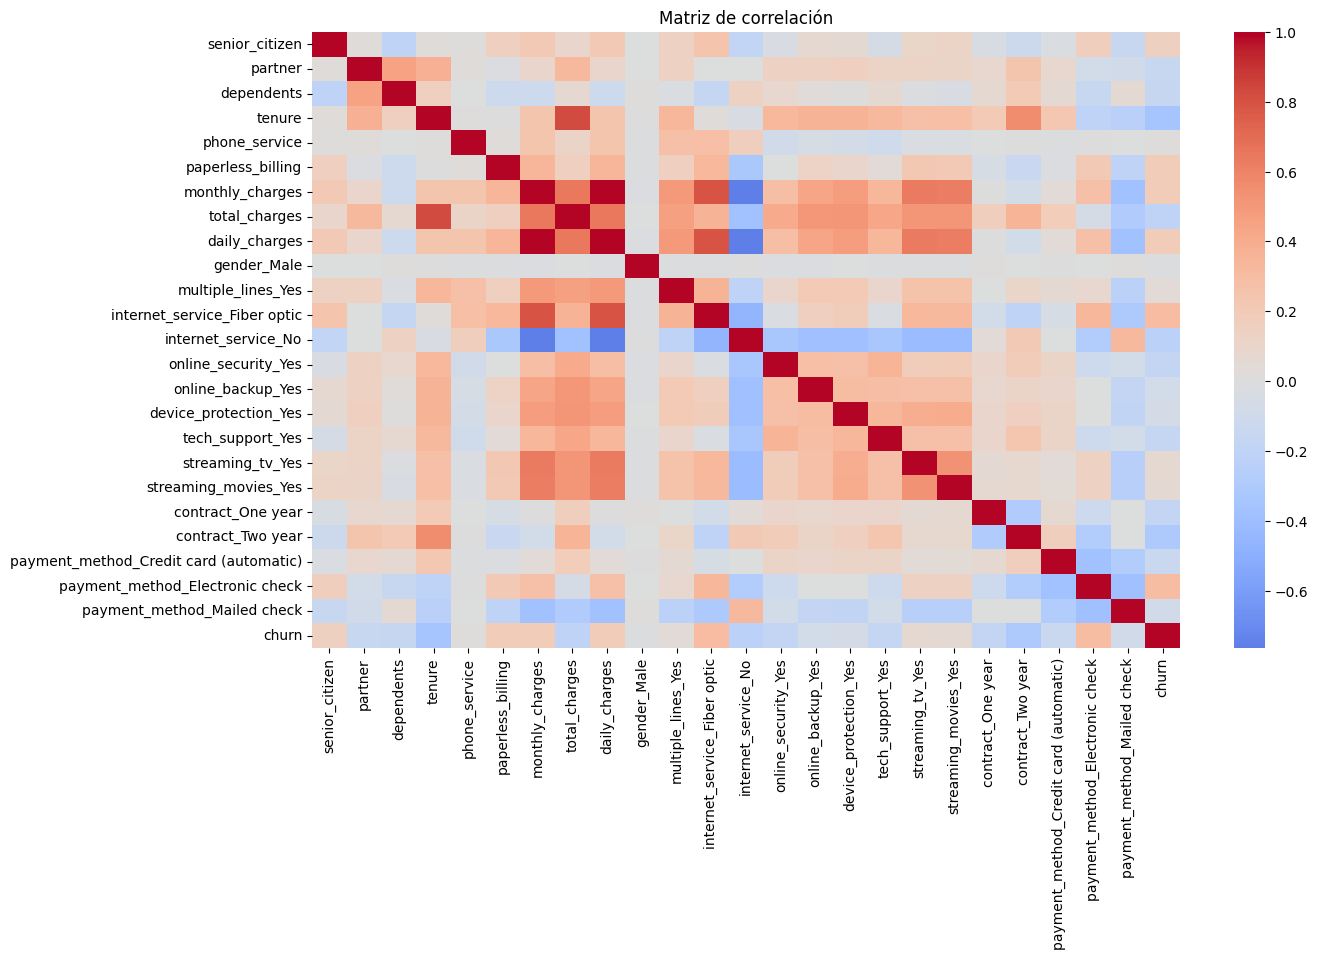

In [21]:
df_model = pd.concat([X_encoded, y], axis=1)

plt.figure(figsize=(14,8))
sns.heatmap(df_model.corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

In [22]:
corr_churn = df_model.corr()['churn'].sort_values(ascending=False)
corr_churn

,churn
churn,1.000000
internet_service_Fiber optic,0.308020
payment_method_Electronic check,0.301919
monthly_charges,0.193356
daily_charges,0.193356
paperless_billing,0.191825
senior_citizen,0.150889
streaming_tv_Yes,0.063228
streaming_movies_Yes,0.061382
multiple_lines_Yes,0.040102


El análisis de correlación permitió identificar qué variables presentan mayor relación lineal con la cancelación. Esta revisión ayuda a detectar posibles factores relevantes para la predicción y orientar la interpretación de los modelos.

#Análisis dirigido

##Boxplot de tenure vs churn

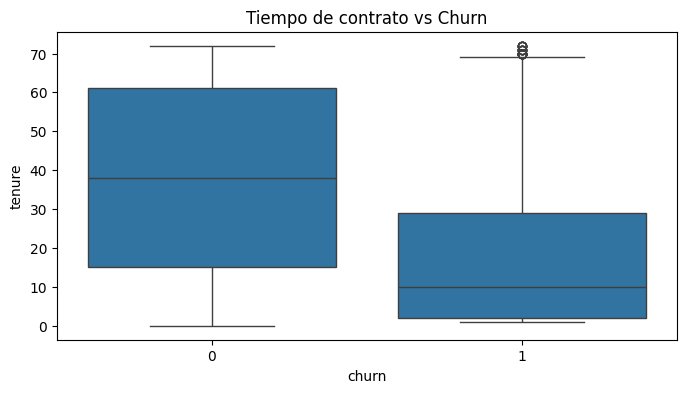

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='tenure')
plt.title('Tiempo de contrato vs Churn')
plt.show()

##Boxplot de total_charges vs churn

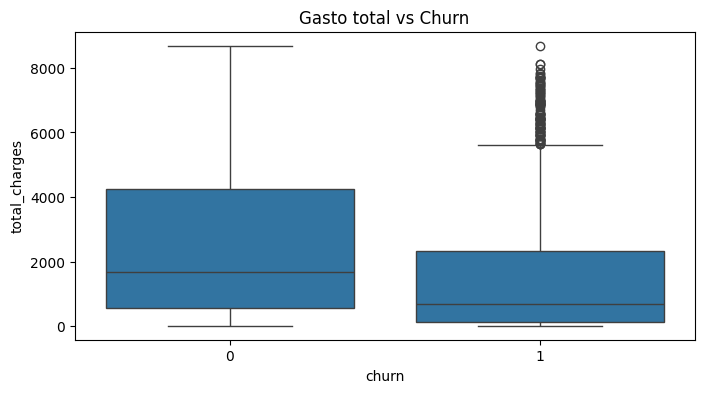

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='total_charges')
plt.title('Gasto total vs Churn')
plt.show()

##Boxplot de monthly_charges vs churn

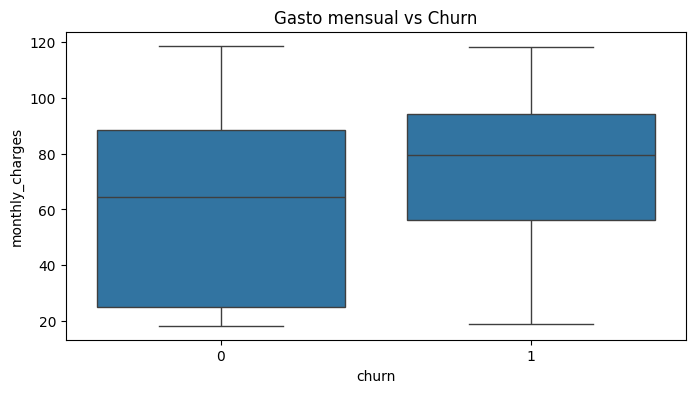

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='churn', y='monthly_charges')
plt.title('Gasto mensual vs Churn')
plt.show()

En el análisis dirigido se observó cómo variables clave como la antigüedad del cliente y los cargos se distribuyen entre quienes cancelan y quienes permanecen. Estas diferencias pueden revelar patrones relevantes para los modelos predictivos.

#Separación en entrenamiento y prueba

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [27]:
print("Distribución en train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en test:")
print(y_test.value_counts(normalize=True))

Distribución en train:
churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Distribución en test:
churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


Se dividieron los datos en 70% para entrenamiento y 30% para prueba, utilizando estratificación para conservar la misma proporción de churn en ambos conjuntos.

##Estandarización

In [28]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Se aplicó estandarización a las variables numéricas para el modelo de Regresión Logística, ya que este algoritmo es sensible a la escala de los datos. En cambio, los modelos basados en árboles no requieren este preprocesamiento.

In [32]:
X_train_scaled.isnull().sum().sort_values(ascending=False).head(20)

,0
total_charges,9
senior_citizen,0
dependents,0
partner,0
tenure,0
phone_service,0
paperless_billing,0
monthly_charges,0
daily_charges,0
gender_Male,0


In [33]:
df = df.dropna()

In [34]:
X = df.drop(columns=['churn'])
y = df['churn']

In [35]:
X.isnull().sum().sum()

np.int64(0)

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_scaled[num_cols] = imputer.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = imputer.transform(X_test_scaled[num_cols])

Durante el entrenamiento del modelo se detectaron valores faltantes (NaN) en algunas variables numéricas.
Dado que modelos como Regresión Logística no aceptan valores nulos, se procedió a eliminar los registros con datos faltantes para garantizar la consistencia del conjunto de datos antes del modelado.

In [39]:
df.isnull().sum()

,0
churn,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


#Modelos
## Modelo 1: Regresión Logística

In [40]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

#Métricas

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

Accuracy: 0.7974443918599148
Precision: 0.6388308977035491
Recall: 0.5454545454545454
F1-score: 0.5884615384615385


In [43]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



##Matriz de confusión

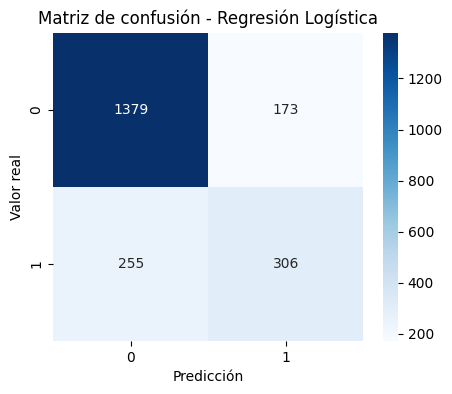

In [44]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

#Modelo 2: Random Forest

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

##Métricas

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.7898722195929957
Precision: 0.6338672768878718
Recall: 0.49376114081996436
F1-score: 0.5551102204408818


In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1552
           1       0.63      0.49      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



##Matriz de confusión

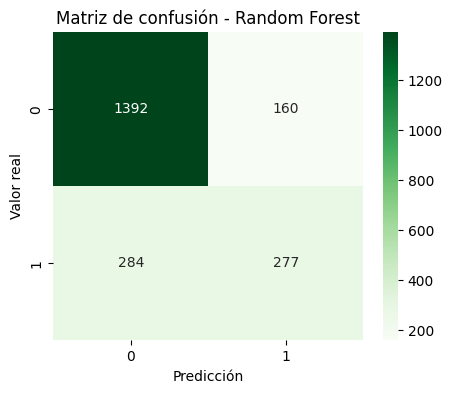

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

#Comparación de modelos

In [49]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.797444,0.638831,0.545455,0.588462
1,Random Forest,0.789872,0.633867,0.493761,0.555110


#Importancia de variables
## Importancia en Regresión Logística

In [50]:
coef_df = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df['Impacto_absoluto'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values(by='Impacto_absoluto', ascending=False)

coef_df.head(15)

,Variable,Coeficiente,Impacto_absoluto
3,tenure,-1.458267,1.458267
20,contract_Two year,-1.293090,1.293090
12,internet_service_No,-0.759363,0.759363
19,contract_One year,-0.726699,0.726699
11,internet_service_Fiber optic,0.708148,0.708148
7,total_charges,0.701309,0.701309
16,tech_support_Yes,-0.432064,0.432064
22,payment_method_Electronic check,0.363816,0.363816
13,online_security_Yes,-0.313973,0.313973
10,multiple_lines_Yes,0.252443,0.252443


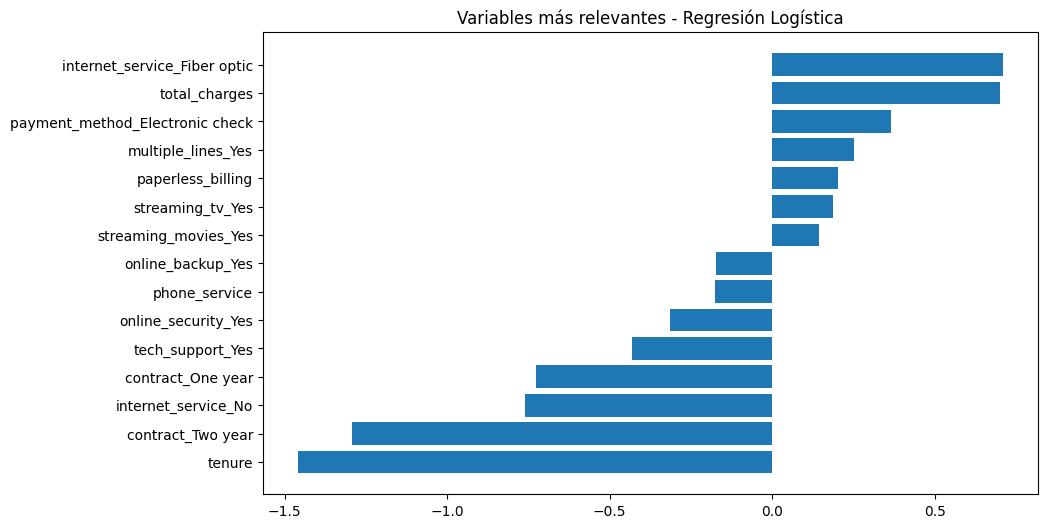

In [51]:
top_coef = coef_df.head(15).sort_values(by='Coeficiente')

plt.figure(figsize=(10,6))
plt.barh(top_coef['Variable'], top_coef['Coeficiente'])
plt.title('Variables más relevantes - Regresión Logística')
plt.show()

**Interpretación**
* coeficiente positivo: aumenta probabilidad de churn
* coeficiente negativo: reduce probabilidad de churn

##Importancia en Random Forest

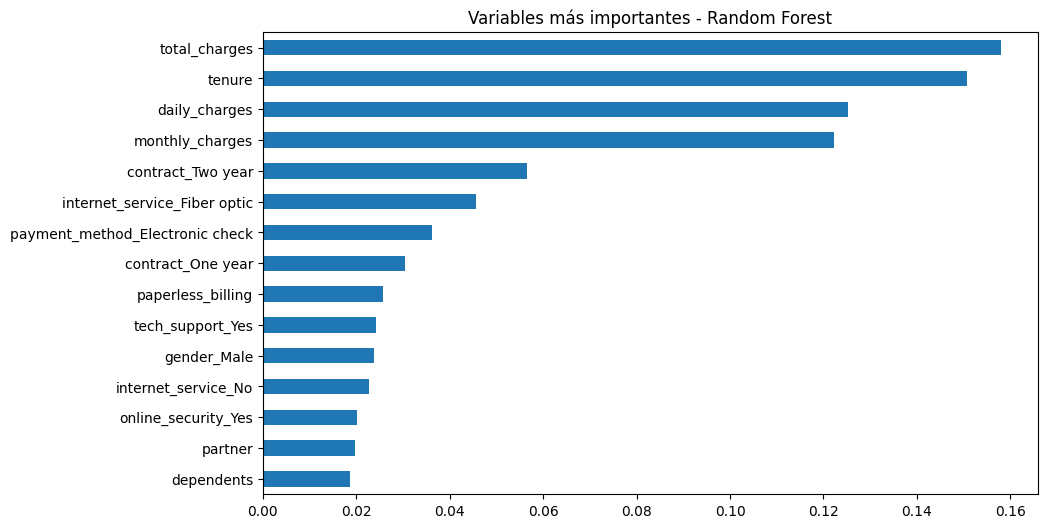

In [52]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_importances.sort_values().plot(kind='barh')
plt.title('Variables más importantes - Random Forest')
plt.show()

# Overfitting / Underfitting

#Regresión Logística

In [53]:
train_pred_log = log_model.predict(X_train_scaled)
test_pred_log = log_model.predict(X_test_scaled)

print("Train accuracy:", accuracy_score(y_train, train_pred_log))
print("Test accuracy:", accuracy_score(y_test, test_pred_log))

Train accuracy: 0.8101419878296146
Test accuracy: 0.7974443918599148


# Random Forest

In [54]:
train_pred_rf = rf_model.predict(X_train)
test_pred_rf = rf_model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred_rf))
print("Test accuracy:", accuracy_score(y_test, test_pred_rf))

Train accuracy: 0.9977687626774848
Test accuracy: 0.7898722195929957


**Interpretación**
* Si train es muy alto y test baja bastante → posible overfitting
* Si ambos son bajos → posible underfitting

## Preparación de los datos
Se utilizó el archivo tratado en la Parte 1 del desafío, asegurando consistencia en la calidad de la información. Se eliminaron columnas irrelevantes como identificadores únicos, se codificaron las variables categóricas mediante one-hot encoding y se evaluó la proporción de churn para verificar la distribución de clases.

## Modelado
Se entrenaron dos modelos de clasificación: Regresión Logística y Random Forest. La Regresión Logística fue seleccionada por ser un modelo interpretable y sensible a la escala, mientras que Random Forest fue elegido por su capacidad de capturar relaciones no lineales y por no requerir normalización.

## Evaluación de modelos
Los modelos fueron evaluados utilizando accuracy, precision, recall, f1-score y matriz de confusión. Dado el contexto del problema, se dio especial importancia al recall, ya que detectar clientes con riesgo de cancelación resulta clave para la empresa.

## Importancia de las variables
El análisis de importancia permitió identificar qué variables influyen más en la cancelación. En la Regresión Logística se analizaron los coeficientes, mientras que en Random Forest se utilizó la importancia de variables calculada por el modelo.

## Conclusión
Los resultados muestran que la cancelación puede predecirse a partir de variables contractuales, financieras y de permanencia del cliente. Esto permite a Telecom X anticiparse al abandono, identificar perfiles de riesgo y priorizar estrategias de fidelización y retención más efectivas.